<a href="https://colab.research.google.com/github/Shreyans06/LLMs-understanding/blob/main/Pre-training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class LayerNorm(nn.Module):
  def __init__(self , emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1 , keepdim=True)
    var = x.var(dim=-1 , keepdim=True , unbiased = False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [3]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self , x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x , 3))
    ))

In [4]:
class FeedForward(nn.Module):
  def __init__(self , cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"] , 4 * cfg["emb_dim"]),
        GELU(),
        nn.Linear(4 * cfg["emb_dim"] , cfg["emb_dim"])
    )

  def forward(self , x):
    return self.layers(x)

In [5]:
class MultiHeadAttention(nn.Module):
  def __init__(self , d_in , d_out , context_length , dropout , num_heads , qkv_bias = False ):
    super().__init__()
    assert (d_out % num_heads == 0) , "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in , d_out , bias = qkv_bias)
    self.W_key = nn.Linear(d_in , d_out , bias = qkv_bias)
    self.W_value = nn.Linear(d_in , d_out , bias = qkv_bias)
    self.out_proj = nn.Linear(d_out , d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length , context_length), diagonal=1)
    )

  def forward(self , x):
    batch , num_tokens , d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    value = self.W_value(x)

    keys = keys.view(batch , num_tokens , self.num_heads , self.head_dim)
    queries = queries.view(batch , num_tokens , self.num_heads , self.head_dim)
    values = queries.view(batch , num_tokens , self.num_heads , self.head_dim)

    keys = keys.transpose(1 , 2)
    queries = queries.transpose(1 , 2)
    values = values.transpose(1 , 2)

    attn_scores = queries @ keys.transpose(2 , 3)
    mask_bool = self.mask.bool()[:num_tokens , :num_tokens]

    attn_scores.masked_fill_(mask_bool , -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1] ** 0.5 , dim= -1
    )

    attn_weights = self.dropout(attn_weights)
    context_vec = (attn_weights @ values).transpose(1 , 2)

    context_vec = context_vec.contiguous().view(
        batch , num_tokens , self.d_out
    )

    context_vec = self.out_proj(context_vec)

    return context_vec


In [6]:
class TransformerBlock(nn.Module):
  def __init__(self , cfg):
    super().__init__()
    self.attn = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length = cfg["context_length"],
        num_heads = cfg["n_heads"],
        dropout = cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ffn = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self , x):
    shortcut = x
    x = self.norm1(x)
    x = self.attn(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    shortcut = x
    x = self.norm2(x)
    x = self.ffn(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    return x

In [7]:
class GPTModel(nn.Module):
  def __init__(self , cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"] , cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"] , cfg["vocab_size"] , bias = False
    )

  def forward(self , in_idx):
    batch_size , seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)

    pos_embeds = self.pos_emb(
        torch.arange(seq_len , device = in_idx.device)
    )

    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

In [8]:
GPT_CONFIG_124M = {
    "vocab_size" : 50257,
    "context_length" : 256,
    "emb_dim" : 768,
    "n_heads" : 12,
    "n_layers" : 12,
    "drop_rate" : 0.1,
    "qkv_bias" : False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_featu

In [9]:
def generate_text_simple(model , idx , max_new_tokens , context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:, -1, :]
    probas = torch.softmax(logits , dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    idx = torch.cat((idx , idx_next), dim=1)

  return idx

In [10]:
import tiktoken

def text_to_token_ids(text , tokenizer):
  encoded = tokenizer.encode(text , allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids , tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context , tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you Tron emptied Dean Angerernel croucomeGeorgia 261


In [11]:
import urllib
url =  ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "verdict.txt"
urllib.request.urlretrieve(url , file_path)

('verdict.txt', <http.client.HTTPMessage at 0x7fbff9b0f890>)

In [12]:
with open(file_path , "r" , encoding="utf-8") as file:
  text_data = file.read()

In [13]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:" , total_characters)
print("Tokens:" , total_tokens)

Characters: 20479
Tokens: 5145


In [14]:
train_ratio = 0.9
split_idx = int(train_ratio * total_characters)
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self , txt , tokenizer , max_length , stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt)

    for i in range(0 , len(token_ids) - max_length , stride):
      input_chunk = token_ids[i : i + max_length]
      target_chunk = token_ids[ i + 1 : i + 1 + max_length]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx] , self.target_ids[idx]

In [16]:
def create_dataloader_v1(txt, batch_size = 4 , max_length = 256 ,
                         stride = 128 , shuffle = True , drop_last = True , num_workers = 0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDatasetV1(txt , tokenizer , max_length , stride)
  # print("Dataset Length:" , len(dataset))
  dataloader = DataLoader(
      dataset,
      batch_size = batch_size,
      shuffle = shuffle,
      drop_last= drop_last,
      num_workers = num_workers
  )
  return dataloader

In [17]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size = 2,
    max_length = GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 2,
    max_length= GPT_CONFIG_124M["context_length"],
    stride = GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [18]:
print("Train Loader")
for x , y in train_loader:
  print(x.shape , y.shape)

print("\nValidation Loader")
for x , y in val_loader:
  print(x.shape , y.shape)

Train Loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation Loader
torch.Size([2, 256]) torch.Size([2, 256])


In [19]:
def calc_loss_batch(input_batch , target_batch , model , device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = F.cross_entropy(logits.flatten(0 , 1) , target_batch.flatten())
  return loss

In [20]:
def calc_loss_loader(data_loader , model , device , num_batches = None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches , len(data_loader))

  for i , (input_batch , target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch , target_batch , model , device
      )
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
  train_loss = calc_loss_loader(train_loader , model , device)
  val_loss = calc_loss_loader(val_loader , model , device)

print("Training loss:" , train_loss)
print("Validation loss:" , val_loss)

Training loss: 11.00633822547065
Validation loss: 11.000394821166992


In [22]:
def evaluate_model(model , train_loader , val_loader , device , eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader , model , device , num_batches=eval_iter
    )

    val_loss = calc_loss_loader(
        val_loader , model , device , num_batches=eval_iter
    )
  model.train()
  return train_loss , val_loss

In [23]:
def generate_and_print_sample(model , tokenizer , device , start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context , tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model = model,
        idx = encoded,
        max_new_tokens=50,
        context_size=context_size
    )

  decoded_text = token_ids_to_text(token_ids , tokenizer)
  print(decoded_text.replace("\n" , " "))
  model.train()

In [24]:
def train_model_simple(model , train_loader , val_loader,
                       optimizer , device , num_epochs,
                       eval_freq , eval_iter , start_context,
                       tokenizer):
  train_losses , val_losses , track_tokens_seen = [] , [] , []
  tokens_seen , global_step = 0 , -1

  for epoch in range(num_epochs):
    model.train()
    for input_batch , target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(
          input_batch , target_batch , model , device
      )
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss , val_loss = evaluate_model(
            model , train_loader , val_loader , device , eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch: {epoch + 1} (Step {global_step:06d}): "
              f"Train loss {train_loss:.3f}, "
              f"Val loss {val_loss:.3f}"
        )
      generate_and_print_sample(
          model , tokenizer , device , start_context
      )
  return train_losses , val_losses , track_tokens_seen

In [25]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 0.0004,
    weight_decay=0.1
)
num_epochs = 10
train_losses , val_losses , tokens_seen = train_model_simple(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer,
    device = device,
    num_epochs = num_epochs,
    eval_freq = 5,
    eval_iter = 5,
    start_context = "Every effort moves you",
    tokenizer = tokenizer

)

Epoch: 1 (Step 000000): Train loss 9.867, Val loss 9.970
Every effort moves you,,,,,,,,,,,,,,.                                   
Every effort moves you,.                                                
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every effort moves you,,,,,,, the the,,,,, the,,,,,,,,,, the the the, the the, the the,,, the the,, the the the the,,,,,
Epoch: 1 (Step 000005): Train loss 8.088, Val loss 8.367
Every effort moves you the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Every effort moves you, the                                                
Every effort moves you,,,,,,,,,,,,.                                     
Every effort moves you,,,,,,,,,,,,.                                     
Every effort moves you,,,,,,

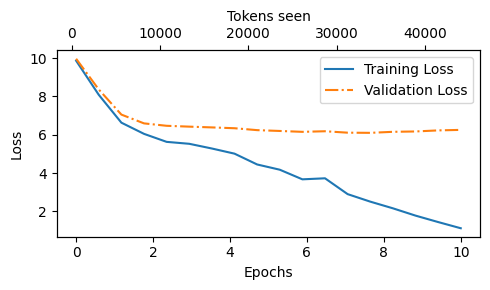

In [26]:
from numpy import integer
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen , tokens_seen , train_losses , val_losses):
  fig , ax1 = plt.subplots(figsize=(5 , 3))
  ax1.plot(epochs_seen , train_losses , label = "Training Loss")
  ax1.plot(epochs_seen , val_losses , linestyle="-." , label="Validation Loss")

  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc="upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

  ax2= ax1.twiny()
  ax2.plot(tokens_seen , train_losses , alpha = 0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show()

# print(train_losses)
epochs_tensor = torch.linspace(0 , num_epochs , len(train_losses))
plot_losses(epochs_tensor , tokens_seen , train_losses , val_losses)

In [27]:
model.to("cpu")

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_featu

In [28]:
model.eval()
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("Every effort moves you" , tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n" , token_ids_to_text(token_ids , tokenizer))


Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me to me to


In [34]:
def generate(model , idx , max_new_tokens , context_size,
             temperature=0.0 , top_k=None , eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1 , :]
    if top_k is not None:
      top_logits , _ = torch.topk(logits , top_k)
      min_val = top_logits[: , -1]
      logits = torch.where(
          logits < min_val,
          torch.tensor(float('-inf')).to(logits.device),
          logits
      )

    if temperature > 0:
      logits = logits / temperature
      probs = torch.softmax(logits , dim=-1)
      idx_next = torch.multinomial(probs , num_samples = 1)
    else:
      idx_next = torch.argmax(logits , dim=-1 , keepdim=True)

    if idx_next == eos_id:
      break

    idx = torch.cat([idx , idx_next] , dim = 1)

  return idx

In [35]:
torch.manual_seed(123)
token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you" , tokenizer),
    max_new_tokens=15,
    context_size = GPT_CONFIG_124M["context_length"],
    top_k = 25,
    temperature = 1.4
)

print("Output text:\n" , token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you not to Gisburn rather a--I felt that told by his painting


In [36]:
!pip install tensorflow>=2.15.0  tqdm>=4.66

In [37]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7fbe76c7b800>)

In [38]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 193kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 655kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 276kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [03:01<00:00, 2.74MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 1.89MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 395kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 436kiB/s]


In [39]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [40]:
print("Token embedding weight tensor dimensions:", params["wte"].shape)

Token embedding weight tensor dimensions: (50257, 768)
